#### UMAP Embedding of Feature Space

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import umap
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
project_name = 'smartt_bmj_open_plus'

In [4]:
save_to_path = Path(f"E:/SMARTT/data/processed/{project_name}")

In [5]:
final_cohort = pd.read_json('..\data\processed\linked_cohort_181024.json', convert_dates=['admitStoreDateTime', 'dischargeStoreDateTime'])

In [6]:
all_samples = pd.read_csv(save_to_path / f"all_24hr_samples_final_cohort_.csv", low_memory=False)

In [7]:
original_features = [
    'Glasgow Coma Scale_ffill', 'temperature_ffill', 'arterial blood pressure (mean)_ffill', 'Fio2_ffill',
    'arterial oxygen saturation_ffill', 'respiratory rate_ffill', 'Heart rate_ffill', 'actual bicarbonate_ffill',
    'Hemoglobin_ffill', 'platelet count_ffill', 'Sodium_ffill', 'potassium_ffill',
    'creatinine_ffill', 'urea_ffill', 'Bilirubin_ffill', 'positive end-expiratory pressure_ffill', 'hours_since_admission'
]

In [8]:
new_features = [
    c
    for c in all_samples.columns
    if '_ffill' in c and c not in original_features and 'trach' not in c
]

In [9]:
all_features = original_features + new_features

In [10]:
all_samples['label'] = [s in ['True', '1', 1] for s in all_samples['label']]

In [11]:
for f in all_samples[original_features + ['hours_since_admission', 'eid'] + new_features]:
    all_samples[f] = pd.to_numeric(all_samples[f], errors='coerce')

In [12]:
 all_samples = all_samples[
     ['time', 'hours_since_admission', 'label', 'eid']
     + all_features
]
# ].dropna()

In [13]:
NNeigh = 5
imputer = KNNImputer(n_neighbors=NNeigh)

In [21]:
impute_features = all_features
all_samples[impute_features] = imputer.fit_transform(all_samples[impute_features])

In [22]:
all_samples.groupby('label').count()

,time,hours_since_admission,eid,Glasgow Coma Scale_ffill,temperature_ffill,arterial blood pressure (mean)_ffill,Fio2_ffill,arterial oxygen saturation_ffill,respiratory rate_ffill,Heart rate_ffill,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
label,,,,,,,,,,,,,,,,,,,,,
False,16796,16807,16796,16807,16807,16807,16807,16807,16807,16807,...,16807,16807,16807,16807,16807,16807,16807,16807,16807,16807
True,4129,4129,4129,4129,4129,4129,4129,4129,4129,4129,...,4129,4129,4129,4129,4129,4129,4129,4129,4129,4129


In [23]:
scaler = StandardScaler()

In [24]:
scaled_samples = all_samples.copy()
# scaled_samples[original_features] = scaler.fit_transform(scaled_samples[original_features])
scaled_samples[all_features] = scaler.fit_transform(scaled_samples[all_features])

In [84]:
np.random.choice([2, 5, 10, 20, 50, 100])

np.int64(2)

In [85]:
n_repeats = 100
umap_params = []
for nr in range(n_repeats):
    reducer = umap.UMAP(
        n_neighbors=np.random.choice([2, 5, 10, 20, 50, 100]),
        min_dist=np.random.choice([0.01, 0.1, 0.3, 0.6, 0.9, 0.99]),
        metric=np.random.choice(['euclidean','manhattan'])
    )
    embedding = reducer.fit_transform(scaled_samples[all_features])

    plt.scatter(
        embedding[scaled_samples.label==0,0],
        embedding[scaled_samples.label==0,1],
        label='NRFD',
        color='r'
    )
    plt.scatter(
        embedding[scaled_samples.label==1,0],
        embedding[scaled_samples.label==1,1],
        label='RFD',
        color='g'
    )
    plt.legend()
    plt.gca().set_aspect('equal', 'datalim')
    plt.savefig(save_to_path / f"figures/umap_randomised_rep_{nr}_all_features.png")

umap_df = pd.DataFrame.from_records(umap_params)

C:\Users\mcwilliamschr\Documents\SMARTT\sniffer_release\SMARTTDataExtraction\newenv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\mcwilliamschr\Documents\SMARTT\sniffer_release\SMARTTDataExtraction\newenv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:455: UserWarning: Exited at iteration 23 with accuracies 
[2.07665889e-04 1.36270665e-04 5.73775559e-05 1.16392396e-03]
not reaching the requested tolerance 5.9291720390319824e-05.
Use iteration 23 instead with accuracy 
0.0003913095186403508.

  _, diffusion_map = lobpcg(
C:\Users\mcwilliamschr\Documents\SMARTT\sniffer_release\SMARTTDataExtraction\newenv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[2.07665890e-04 1.36270664e-04 5.73775558e-05 1.16392396e-03]
not reaching the requested tolerance 5.9291720390319824e-05.
  _, diffu

KeyboardInterrupt: 

C:\Users\mcwilliamschr\Documents\SMARTT\sniffer_release\SMARTTDataExtraction\newenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


Error in callback <function flush_figures at 0x000001EA480CB2E0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [26]:
embedding = reducer.fit_transform(scaled_samples[all_features])

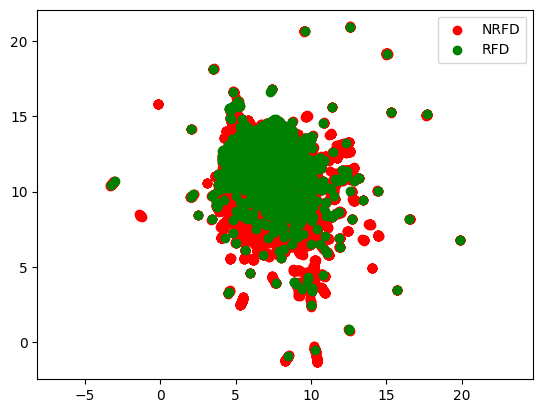

In [83]:

plt.scatter(
    embedding[scaled_samples.label==0,0],
    embedding[scaled_samples.label==0,1],
    label='NRFD',
    color='r'
)
plt.scatter(
    embedding[scaled_samples.label==1,0],
    embedding[scaled_samples.label==1,1],
    label='RFD',
    color='g'
)
plt.legend()
plt.gca().set_aspect('equal', 'datalim')
plt.savefig(save_to_path / f"figures/test.png")

#### Looking at only the final samples we get the clinically ready for discharge time point:

In [50]:
final_samples = scaled_samples.groupby('eid').last().reset_index()

In [52]:
final_samples.groupby('label').count()

,eid,time,hours_since_admission,Glasgow Coma Scale_ffill,temperature_ffill,arterial blood pressure (mean)_ffill,Fio2_ffill,arterial oxygen saturation_ffill,respiratory rate_ffill,Heart rate_ffill,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
label,,,,,,,,,,,,,,,,,,,,,
False,1084,1084,1084,1084,1084,1084,1084,1084,1084,1084,...,1084,1084,1084,1084,1084,1084,1084,1084,1084,1084
True,4129,4129,4129,4129,4129,4129,4129,4129,4129,4129,...,4129,4129,4129,4129,4129,4129,4129,4129,4129,4129


In [60]:
desired_class_size = len(scaled_samples[scaled_samples.label==1])
balanced_scaled_samples = pd.concat([
    scaled_samples[scaled_samples.label==1],
    scaled_samples[scaled_samples.label==0].sample(n=desired_class_size)
])

# desired_class_size = len(final_samples[final_samples.label==0])
# balanced_scaled_samples = pd.concat([
#     final_samples[final_samples.label==1].sample(n=desired_class_size),
#     final_samples[final_samples.label==0]
# ])

In [61]:
train, test = train_test_split(final_cohort[final_cohort['Declared clinically ready for discharge']=='Yes'], test_size=0.2)

In [62]:
# train, test = train_test_split(scaled_samples, test_size=0.2)
train = balanced_scaled_samples[balanced_scaled_samples.eid.isin(train.encounterId)]
test = balanced_scaled_samples[balanced_scaled_samples.eid.isin(test.encounterId)]

In [74]:
# train_embedding = reducer.fit_transform(train[all_features])
# reducer = umap.UMAP(n_neighbors=20, min_dist=0.3, metric='manhattan')
# reducer = umap.UMAP(metric='manhattan')
reducer = umap.UMAP()
train_embedding = reducer.fit_transform(train[original_features])

In [80]:
# neg_outcome = balanced_scaled_samples[balanced_scaled_samples.eid.isin(
#     final_cohort[final_cohort.outcome==0].encounterId
# )
neg_outcome = final_samples[final_samples.eid.isin(
    final_cohort[final_cohort.outcome==0].encounterId
)
]
neg_outcome = reducer.transform(neg_outcome[original_features])

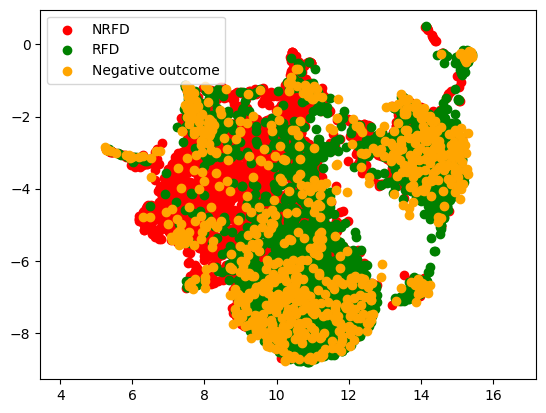

In [81]:

plt.scatter(
    train_embedding[train.label==0,0],
    train_embedding[train.label==0,1],
    label='NRFD',
    color='r'
)
plt.scatter(
    train_embedding[train.label==1,0],
    train_embedding[train.label==1,1],
    label='RFD',
    color='g'
)
plt.scatter(
    neg_outcome[:,0],
    neg_outcome[:,1],
    label='Negative outcome',
    color='orange'
)
plt.legend()
plt.gca().set_aspect('equal', 'datalim')

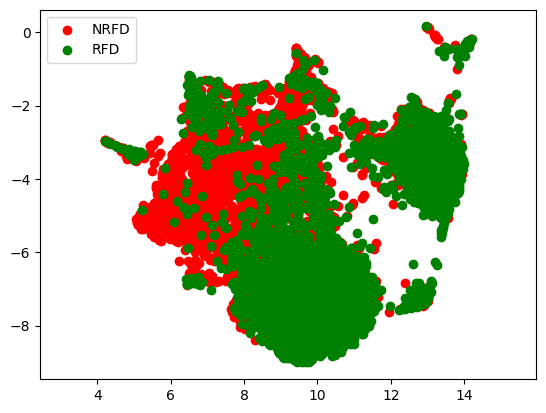

In [64]:

plt.scatter(
    train_embedding[train.label==0,0],
    train_embedding[train.label==0,1],
    label='NRFD',
    color='r'
)
plt.scatter(
    train_embedding[train.label==1,0],
    train_embedding[train.label==1,1],
    label='RFD',
    color='g'
)
plt.legend()
plt.gca().set_aspect('equal', 'datalim')